In [1]:
import pandas as pd

df = pd.read_csv('titanic_train.csv')

In [2]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Exploratory Data Analysis (EDA)

<li> How many passengers in total were there?
<li> How many passengers survived?
<li> How many people were in each class (first, second, third)?
<li> How old was the youngest/oldest passanger?
<li> What was the distribution of ages among passengers?
<li> How many men were on the ship? Women?

#### How many passengers were there?

In [5]:
df.shape # this returns (# of rows, # of cols)

(891, 12)

#### How many passengers survived?

In [10]:
survived = df['Survived'].sum()
print(f'{survived} people survived the Titanic')

# bonus: how many people didn't survive?
print(df['Survived'].value_counts())

342 people survived the Titanic
0    549
1    342
Name: Survived, dtype: int64


##### A quick aside on how to refer to columns...

In [11]:
print(df['Survived'].sum())
print(df.Survived.sum())

342
342


#### How many people of each class where there?

In [19]:
print(df['Pclass'].value_counts())

3    491
1    216
2    184
Name: Pclass, dtype: int64


In [22]:
# to put the above in order, we can use the .sort_index() method
print(df["Pclass"].value_counts().sort_index())

1    216
2    184
3    491
Name: Pclass, dtype: int64


#### How old was the youngest/oldest passenger?

In [17]:
print(df["Age"].min())
print(df["Age"].max())

print(df["Age"].describe())

0.42
80.0
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64


<AxesSubplot:>

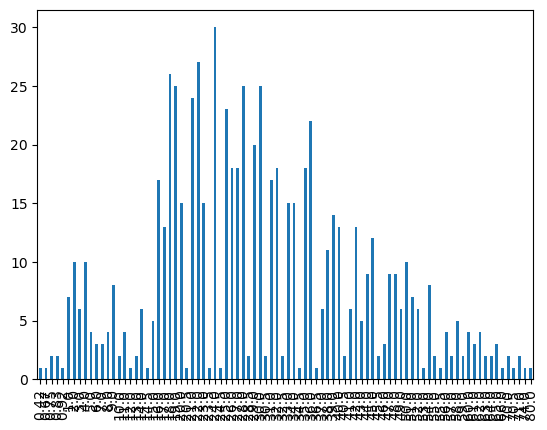

In [27]:
df["Age"].value_counts().sort_index().plot(kind='bar')

# the above is like:
# fig, my_ax = plt.subplots((1,1))

<AxesSubplot:>

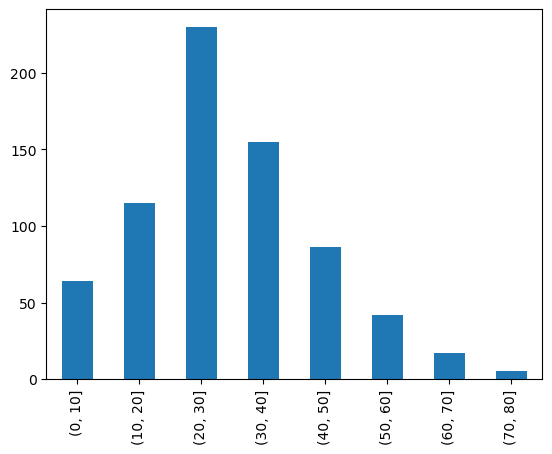

In [29]:
bins = [edge for edge in range(0,90,10)]

df["AgeBin"] = pd.cut(df["Age"], bins)

df["AgeBin"].value_counts().sort_index().plot(kind='bar')


#### Women and Children first?

In [6]:
# select rows by Boolean condition
len(df.loc[(df['Survived']==1) & (df['Sex']=='female')])

233

#### Class warfare!  Did being a first class passenger help your survival?